In [1]:
# Install sklearn
!pip install scikit-learn==1.5.2

# Install TabPFN API Client
!pip install tabpfn-client

# TabPFN Extensions installs optional functionalities around the TabPFN model
# These include post-hoc ensembles, interpretability tools, and more
!git clone https://github.com/PriorLabs/tabpfn-extensions
!pip install -e tabpfn-extensions
!pip install tabpfn # TabPFN, currently required by tabpfn-extensions, but not basic usage


# Install Baselines
!pip install catboost xgboost

# Install example datasets
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 78.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 52.9 MB/s eta 0:00:00
Cloning into 'tabpfn-extensions'...
remote: Enumerating objects: 2089, done.
remote: Counting objects: 100% (288/288), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 2089 (delta 209), reused 175 (delta 175), pack-reused 1801 (from 2)
Receiving objects: 100% (2089/2089), 775.16 KiB | 23.49 MiB/s, done.
Resolving deltas: 100% (1273/1273), done.
Obtaining file:///content/tabpfn-extensions
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128

In [2]:
pip install skfeature-chappers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 6.6 MB/s eta 0:00:00


In [3]:
pip install nanopq

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from nanopq import PQ  # Make sure you have nanopq installed: pip install nanopq
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from skfeature.function.information_theoretical_based import CMIM, JMI
import gc
import time
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from tabpfn import TabPFNClassifier

In [5]:
# Load data
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
#data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-CIC-2020.csv")
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)

In [ ]:
data

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Class
0,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,1
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7125,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7126,0,0,0,1,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7128,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

In [ ]:
# record start time
start = time.time()
#f, t, p = JMI.jmi(X_train,y_train, n_selected_features = 5)
f = JMI.jmi(X_train, y_train, n_selected_features=100 )
end = time.time()

# print the difference between start
# and end time in milli. secs
print("The time of execution of above program is :",
      (end-start), "sec")

The time of execution of above program is : 72.02252864837646 sec


In [ ]:
f

array([41, 28, 29, 47, 70, 20, 36, 66, 71,  6, 18, 45, 21, 76, 83, 13, 86,
        4, 53, 52, 14, 44, 77, 72, 46, 97, 24, 88, 11, 91, 93, 16, 82, 40,
       78, 63, 67, 50, 27, 23, 54, 79, 51, 84, 42, 61, 99, 10, 95, 90, 85,
       75, 73, 68, 58, 39, 35, 34, 33, 31, 15, 12,  7,  5, 87,  3,  2,  0,
       80, 17, 57, 62,  9, 94, 55, 64,  8, 48, 98, 96, 92, 89, 81, 74, 69,
       65, 60, 59, 56, 49, 43, 38, 37, 32, 30, 26, 25, 22, 19,  1])

In [ ]:
len(f)

100

In [6]:
f = [41, 28, 29, 47, 70, 20, 36, 66, 71,  6, 18, 45, 21, 76, 83, 13, 86,
        4, 53, 52, 14, 44, 77, 72, 46, 97, 24, 88, 11, 91, 93, 16, 82, 40,
       78, 63, 67, 50, 27, 23, 54, 79, 51, 84, 42, 61, 99, 10, 95, 90, 85,
       75, 73, 68, 58, 39, 35, 34, 33, 31, 15, 12,  7,  5, 87,  3,  2,  0,
       80, 17, 57, 62,  9, 94, 55, 64,  8, 48, 98, 96, 92, 89, 81, 74, 69,
       65, 60, 59, 56, 49, 43, 38, 37, 32, 30, 26, 25, 22, 19,  1]

In [7]:
f = np.array(f)
f

array([41, 28, 29, 47, 70, 20, 36, 66, 71,  6, 18, 45, 21, 76, 83, 13, 86,
        4, 53, 52, 14, 44, 77, 72, 46, 97, 24, 88, 11, 91, 93, 16, 82, 40,
       78, 63, 67, 50, 27, 23, 54, 79, 51, 84, 42, 61, 99, 10, 95, 90, 85,
       75, 73, 68, 58, 39, 35, 34, 33, 31, 15, 12,  7,  5, 87,  3,  2,  0,
       80, 17, 57, 62,  9, 94, 55, 64,  8, 48, 98, 96, 92, 89, 81, 74, 69,
       65, 60, 59, 56, 49, 43, 38, 37, 32, 30, 26, 25, 22, 19,  1])

In [8]:
len(f)

100

In [ ]:
f[0:100]

array([41, 28, 29, 47, 70, 20, 36, 66, 71,  6, 18, 45, 21, 76, 83, 13, 86,
        4, 53, 52, 14, 44, 77, 72, 46, 97, 24, 88, 11, 91, 93, 16, 82, 40,
       78, 63, 67, 50, 27, 23, 54, 79, 51, 84, 42, 61, 99, 10, 95, 90, 85,
       75, 73, 68, 58, 39, 35, 34, 33, 31, 15, 12,  7,  5, 87,  3,  2,  0,
       80, 17, 57, 62,  9, 94, 55, 64,  8, 48, 98, 96, 92, 89, 81, 74, 69,
       65, 60, 59, 56, 49, 43, 38, 37, 32, 30, 26, 25, 22, 19,  1])

In [9]:
selected_features_names=[]
for i in range(len(f[0:100])):
    selected_features_names.append(data.columns[f[i]])
selected_features_names

['BIND_VPN_SERVICE',
 'BIND_APPWIDGET',
 'BIND_CARRIER_MESSAGING_SERVICE',
 'BRICK',
 'DELETE_CACHE_FILES',
 'ANT',
 'BIND_PRINT_SERVICE',
 'CLEAR_APP_CACHE',
 'DELETE_PACKAGES',
 'ACCESS_LOCATION_EXTRA_COMMANDS',
 'ACCOUNT_MANAGER',
 'BLUETOOTH_PRIVILEGED',
 'ANT_ADMIN',
 'DOWNLOAD_WITHOUT_goodwareTIFICATION',
 'FULLSCREEN.FULL',
 'ACCESS_SUPERUSER',
 'GET_TASKS',
 'ACCESS_COARSE_UPDATES',
 'CALL_PHONE',
 'C2D_MESSAGE',
 'ACCESS_SURFACE_FLINGER',
 'BLUETOOTH_ADMIN',
 'DUMP',
 'DEVICE_POWER',
 'BODY_SENSORS',
 'INTERNAL_SYSTEM_WINDOW',
 'AUTORUN_MANAGER_LICENSE_SERVICE(.autorun)',
 'GLOBAL_SEARCH',
 'ACCESS_SERVICE',
 'HARDWARE_TEST',
 'INSTALL_LOCATION_PROVIDER',
 'activityCalled',
 'FORCE_BACK',
 'BIND_VOICE_INTERACTION',
 'EXPAND_STATUS_BAR',
 'CHANGE_WIFI_MULTICAST_STATE',
 'CLEAR_APP_USER_DATA',
 'BROADCAST_STICKY',
 'BIND_ACCESSIBILITY_SERVICE',
 'AUTORUN_MANAGER_LICENSE_MANAGER',
 'CALL_PRIVILEGED',
 'EXTENSION_PERMISSION',
 'BROADCAST_WAP_PUSH',
 'GET_ACCOUNTS',
 'BIND_WALLPAPE

In [10]:
len(selected_features_names)

100

In [ ]:
from tabpfn import TabPFNClassifier

tab_pfn_={
    "acc":{"index":[],"val":[],},
    "per":{"index":[],"val":[],},
    "rec":{"index":[],"val":[],},
    "f1s":{"index":[],"val":[],},
    "auc":{"index":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
for i in range(2,len(selected_features_names)+1,2):
    X = data[selected_features_names[:i]].values  # Features
    y = data.iloc[:, -1].values   # Binary labels (0 or 1)
    start = time.time()
    pq_pq = PQ(M=int(i/2), Ks=2)
    pq_pq.fit(X.astype(np.float32))
    codes_pq = pq_pq.encode(X.astype(np.float32))
    end = time.time()

    # print the difference between start
    # and end time in milli. secs
    print("The time of execution of above program is :",
          (end-start), "sec")
    X_train, X_test, y_train, y_test = train_test_split(codes_pq,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
    # Initialize a classifier
    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")
    tab_pfn_["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_["acc"]['index'].append(i)
    tab_pfn_["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_["per"]['index'].append(i)
    tab_pfn_["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_["rec"]['index'].append(i)
    tab_pfn_["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_["f1s"]['index'].append(i)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_["auc"]['index'].append(i)

M: 1, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 1
Encoding the subspace: 0 / 1
The time of execution of above program is : 0.0052378177642822266 sec


/usr/local/lib/python3.11/dist-packages/nanopq/pq.py:123: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  self.codewords[m], _ = kmeans2(vecs_sub, self.Ks, iter=iter, minit=minit)


The time of execution of training the tabpfn is : 209.10547280311584 sec
The time of execution of testing sample with the tabpfn is : 0.0005759719712202546 sec
M: 2, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 2
Training the subspace: 1 / 2
Encoding the subspace: 0 / 2
Encoding the subspace: 1 / 2
The time of execution of above program is : 0.018558502197265625 sec


/usr/local/lib/python3.11/dist-packages/nanopq/pq.py:123: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  self.codewords[m], _ = kmeans2(vecs_sub, self.Ks, iter=iter, minit=minit)


The time of execution of training the tabpfn is : 207.94842338562012 sec
The time of execution of testing sample with the tabpfn is : 0.0007391288604843332 sec
M: 3, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 3
Training the subspace: 1 / 3
Training the subspace: 2 / 3
Encoding the subspace: 0 / 3
Encoding the subspace: 1 / 3
Encoding the subspace: 2 / 3
The time of execution of above program is : 0.014244318008422852 sec


...

Training the subspace: 34 / 48
Training the subspace: 35 / 48
Training the subspace: 36 / 48
Training the subspace: 37 / 48
Training the subspace: 38 / 48
Training the subspace: 39 / 48
Training the subspace: 40 / 48
Training the subspace: 41 / 48
Training the subspace: 42 / 48
Training the subspace: 43 / 48
Training the subspace: 44 / 48
Training the subspace: 45 / 48
Training the subspace: 46 / 48
Training the subspace: 47 / 48
Encoding the subspace: 0 / 48
Encoding the subspace: 1 / 48
Encoding the subspace: 2 / 48
Encoding the subspace: 3 / 48
Encoding the subspace: 4 / 48
Encoding the subspace: 5 / 48
Encoding the subspace: 6 / 48
Encoding the subspace: 7 / 48
Encoding the subspace: 8 / 48
Encoding the subspace: 9 / 48
Encoding the subspace: 10 / 48
Encoding the subspace: 11 / 48
Encoding the subspace: 12 / 48
Encoding the subspace: 13 / 48
Encoding the subspace: 14 / 48
Encoding the subspace: 15 / 48
Encoding the subspace: 16 / 48
Encoding the subspace: 17 / 48
Encoding the subsp

/usr/local/lib/python3.11/dist-packages/nanopq/pq.py:123: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  self.codewords[m], _ = kmeans2(vecs_sub, self.Ks, iter=iter, minit=minit)


Training the subspace: 48 / 49
Encoding the subspace: 0 / 49
Encoding the subspace: 1 / 49
Encoding the subspace: 2 / 49
Encoding the subspace: 3 / 49
Encoding the subspace: 4 / 49
Encoding the subspace: 5 / 49
Encoding the subspace: 6 / 49
Encoding the subspace: 7 / 49
Encoding the subspace: 8 / 49
Encoding the subspace: 9 / 49
Encoding the subspace: 10 / 49
Encoding the subspace: 11 / 49
Encoding the subspace: 12 / 49
Encoding the subspace: 13 / 49
Encoding the subspace: 14 / 49
Encoding the subspace: 15 / 49
Encoding the subspace: 16 / 49
Encoding the subspace: 17 / 49
Encoding the subspace: 18 / 49
Encoding the subspace: 19 / 49
Encoding the subspace: 20 / 49
Encoding the subspace: 21 / 49
Encoding the subspace: 22 / 49
Encoding the subspace: 23 / 49
Encoding the subspace: 24 / 49
Encoding the subspace: 25 / 49
Encoding the subspace: 26 / 49
Encoding the subspace: 27 / 49
Encoding the subspace: 28 / 49
Encoding the subspace: 29 / 49
Encoding the subspace: 30 / 49
Encoding the subsp

/usr/local/lib/python3.11/dist-packages/nanopq/pq.py:123: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  self.codewords[m], _ = kmeans2(vecs_sub, self.Ks, iter=iter, minit=minit)


Training the subspace: 47 / 50
Training the subspace: 48 / 50
Training the subspace: 49 / 50
Encoding the subspace: 0 / 50
Encoding the subspace: 1 / 50
Encoding the subspace: 2 / 50
Encoding the subspace: 3 / 50
Encoding the subspace: 4 / 50
Encoding the subspace: 5 / 50
Encoding the subspace: 6 / 50
Encoding the subspace: 7 / 50
Encoding the subspace: 8 / 50
Encoding the subspace: 9 / 50
Encoding the subspace: 10 / 50
Encoding the subspace: 11 / 50
Encoding the subspace: 12 / 50
Encoding the subspace: 13 / 50
Encoding the subspace: 14 / 50
Encoding the subspace: 15 / 50
Encoding the subspace: 16 / 50
Encoding the subspace: 17 / 50
Encoding the subspace: 18 / 50
Encoding the subspace: 19 / 50
Encoding the subspace: 20 / 50
Encoding the subspace: 21 / 50
Encoding the subspace: 22 / 50
Encoding the subspace: 23 / 50
Encoding the subspace: 24 / 50
Encoding the subspace: 25 / 50
Encoding the subspace: 26 / 50
Encoding the subspace: 27 / 50
Encoding the subspace: 28 / 50
Encoding the subsp

In [ ]:
print("the highest accuracy where the number of features is: ", tab_pfn_["acc"]['index'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest accuracy value is: ", tab_pfn_["acc"]['val'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest AUC where the number of features is: ", tab_pfn_["auc"]['index'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest AUC value is: ", tab_pfn_["auc"]['val'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest precision where the number of features is: ", tab_pfn_["per"]['index'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest precision value is: ", tab_pfn_["per"]['val'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest recall where the number of features is: ", tab_pfn_["rec"]['index'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest recall value is: ", tab_pfn_["rec"]['val'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest f1_score where the number of features is: ", tab_pfn_["f1s"]['index'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])
print("the highest f1_score value is: ", tab_pfn_["f1s"]['val'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])

the highest accuracy where the number of features is:  100
the highest accuracy value is:  0.9417952314165497
the highest AUC where the number of features is:  100
the highest AUC value is:  0.9732768117082383
the highest precision where the number of features is:  2
the highest precision value is:  1.0
the highest recall where the number of features is:  6
the highest recall value is:  1.0
the highest f1_score where the number of features is:  100
the highest f1_score value is:  0.9397240377632534


In [ ]:
tab_pfn_

{'acc': {'index': [2,
   4,
   6,
   8,
   10,
   12,
   14,
   16,
   18,
   20,
   22,
   24,
   26,
   28,
   30,
   32,
   34,
   36,
   38,
   40,
   42,
   44,
   46,
   48,
   50,
   52,
   54,
   56,
   58,
   60,
   62,
   64,
   66,
   68,
   70,
   72,
   74,
   76,
   78,
   80,
   82,
   84,
   86,
   88,
   90,
   92,
   94,
   96,
   98,
   100],
  'val': [0.5014025245441796,
   0.5021037868162693,
   0.5021037868162693,
   0.5021037868162693,
   0.511921458625526,
   0.511921458625526,
   0.5154277699859747,
   0.5161290322580645,
   0.8597475455820477,
   0.8597475455820477,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.8639551192145862,
   0.864656381486676,
   0.864656381486676,
   0.8653576437587658,
   0.864656381486676,
   0.864656381486676,
   0.864656381

In [ ]:
tab_pfn_ = { 'acc': {'index': [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50,52,54,56,58,60,62,64,66,68,70,72,74,76,78,80,82,84,86,88,90,92,94,96,98,100],
  'val': [0.5014025245441796,0.5021037868162693,0.5021037868162693,0.5021037868162693,0.511921458625526,0.511921458625526,0.5154277699859747,0.5161290322580645,0.8597475455820477,0.8597475455820477,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.8639551192145862,0.864656381486676,0.864656381486676,0.8653576437587658,0.864656381486676,0.864656381486676,0.864656381486676,0.864656381486676,0.864656381486676,0.8674614305750351,0.879382889200561,0.8800841514726507,0.8800841514726507,0.8800841514726507,0.8821879382889201,0.8835904628330996,0.9109396914446003,0.9102384291725105,0.9109396914446003,0.9109396914446003,0.9109396914446003,0.9109396914446003,0.9109396914446003,0.9109396914446003,0.9130434782608695,0.9130434782608695,0.9123422159887798,0.9389901823281908,0.9417952314165497]},
 'per': {'index': [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50,52,54,56,58,60,62,64,66,68,70,72,74,76,78,80,82,84,86,88,90,92,94,96,98,100],
  'val': [np.float64(1.0),np.float64(1.0),np.float64(0.5021037868162693),np.float64(0.5021037868162693),np.float64(0.5070821529745042),np.float64(0.5070821529745042),np.float64(0.5088841506751954),np.float64(0.5092460881934566),np.float64(0.9448275862068966),np.float64(0.9448275862068966),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.9547038327526133),np.float64(0.956369982547993),np.float64(0.956369982547993),np.float64(0.958041958041958),np.float64(0.956369982547993),np.float64(0.956369982547993),np.float64(0.956369982547993),np.float64(0.956369982547993),np.float64(0.956369982547993),np.float64(0.9535283993115319),np.float64(0.9788732394366197),np.float64(0.9805996472663139),np.float64(0.9805996472663139),np.float64(0.9805996472663139),np.float64(0.9858156028368794),np.float64(0.9875886524822695),np.float64(0.975767366720517),np.float64(0.9757281553398058),np.float64(0.975767366720517),np.float64(0.975767366720517),np.float64(0.975767366720517),np.float64(0.975767366720517),np.float64(0.975767366720517),np.float64(0.975767366720517),np.float64(0.9789644012944984),np.float64(0.9789644012944984),np.float64(0.9789303079416531),np.float64(0.9729323308270676),np.float64(0.9788199697428139)]},
 'rec': {'index': [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50,52,54,56,58,60,62,64,66,68,70,72,74,76,78,80,82,84,86,88,90,92,94,96,98,100],
  'val': [np.float64(0.006983240223463687),np.float64(0.008379888268156424),np.float64(1.0),np.float64(1.0),np.float64(1.0),np.float64(1.0),np.float64(1.0),np.float64(1.0),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7653631284916201),np.float64(0.7737430167597765),np.float64(0.776536312849162),np.float64(0.776536312849162),np.float64(0.776536312849162),np.float64(0.776536312849162),np.float64(0.776536312849162),np.float64(0.7779329608938548),np.float64(0.8435754189944135),np.float64(0.8421787709497207),np.float64(0.8435754189944135),np.float64(0.8435754189944135),np.float64(0.8435754189944135),np.float64(0.8435754189944135),np.float64(0.8435754189944135),np.float64(0.8435754189944135),np.float64(0.8449720670391061),np.float64(0.8449720670391061),np.float64(0.8435754189944135),np.float64(0.9036312849162011),np.float64(0.9036312849162011)]},
 'f1s': {'index': [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50,52,54,56,58,60,62,64,66,68,70,72,74,76,78,80,82,84,86,88,90,92,94,96,98,100],
  'val': [np.float64(0.013869625520110958),np.float64(0.01662049861495845),np.float64(0.6685340802987861),np.float64(0.6685340802987861),np.float64(0.6729323308270677),np.float64(0.6729323308270677),np.float64(0.6745171926519077),np.float64(0.6748350612629594),np.float64(0.845679012345679),np.float64(0.845679012345679),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8496124031007752),np.float64(0.8502715283165244),np.float64(0.8502715283165244),np.float64(0.8509316770186336),np.float64(0.8502715283165244),np.float64(0.8502715283165244),np.float64(0.8502715283165244),np.float64(0.8502715283165244),np.float64(0.8502715283165244),np.float64(0.8542791056283732),np.float64(0.8660436137071651),np.float64(0.8667186282151208),np.float64(0.8667186282151208),np.float64(0.8667186282151208),np.float64(0.86875),np.float64(0.8703125),np.float64(0.9048689138576779),np.float64(0.904047976011994),np.float64(0.9048689138576779),np.float64(0.9048689138576779),np.float64(0.9048689138576779),np.float64(0.9048689138576779),np.float64(0.9048689138576779),np.float64(0.9048689138576779),np.float64(0.9070464767616192),np.float64(0.9070464767616192),np.float64(0.9062265566391597),np.float64(0.9370021723388848),np.float64(0.9397240377632534)]},
 'auc': {'index': [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,32,34,36,38,40,42,44,46,48,50,52,54,56,58,60,62,64,66,68,70,72,74,76,78,80,82,84,86,88,90,92,94,96,98,100],
  'val': [np.float64(0.5034916201117319),np.float64(0.5041899441340782),np.float64(0.5041899441340782),np.float64(0.5062849162011174),np.float64(0.5235502399874105),np.float64(0.5235502399874105),np.float64(0.5269730112518688),np.float64(0.5276575655047604),np.float64(0.8643677708710362),np.float64(0.8667371547722086),np.float64(0.8766602407742545),np.float64(0.8766602407742545),np.float64(0.8766602407742545),np.float64(0.8766602407742545),np.float64(0.8766602407742545),np.float64(0.8768176095680227),np.float64(0.8768176095680227),np.float64(0.877980171531985),np.float64(0.8783017940042488),np.float64(0.8783017940042488),np.float64(0.8786234164765127),np.float64(0.8862243292155165),np.float64(0.8862223621055945),np.float64(0.8862223621055945),np.float64(0.8859253285073571),np.float64(0.8865508694625855),np.float64(0.8865449681328192),np.float64(0.8865390668030529),np.float64(0.8856066566999764),np.float64(0.8862400660948934),np.float64(0.9146618538043906),np.float64(0.9239957903847668),np.float64(0.9259294594381934),np.float64(0.925744551105516),np.float64(0.9262953418837045),np.float64(0.9273811865607052),np.float64(0.9504130930836415),np.float64(0.9597047368006925),np.float64(0.9598817766936817),np.float64(0.9608761507593044),np.float64(0.9607050121960815),np.float64(0.960982374695098),np.float64(0.960982374695098),np.float64(0.9612243292155166),np.float64(0.9616295538594695),np.float64(0.9622226375009835),np.float64(0.9624370524824928),np.float64(0.9626573687937681),np.float64(0.9727476591391927),np.float64(0.9732768117082383)]} }

In [ ]:
len(tab_pfn_["acc"]['val'])

50

In [ ]:
tab_pfn_["acc"]['val'][49]

0.9417952314165497

In [ ]:
tab_pfn_["auc"]['val'][49]

0.9732768117082383

In [ ]:
tab_pfn_["per"]['val'][49]

0.9788199697428139

In [ ]:
tab_pfn_["rec"]['val'][49]

0.9036312849162011

In [ ]:
tab_pfn_["f1s"]['val'][49]

0.9397240377632534

In [ ]:
tab_pfn_

{'acc': {'index': [2,
   4,
   6,
   8,
   10,
   12,
   14,
   16,
   18,
   20,
   22,
   24,
   26,
   28,
   30,
   32,
   34,
   36,
   38,
   40,
   42,
   44,
   46,
   48,
   50,
   52,
   54,
   56,
   58,
   60,
   62,
   64,
   66,
   68,
   70,
   72,
   74,
   76,
   78,
   80,
   82,
   84,
   86,
   88,
   90,
   92,
   94,
   96,
   98,
   100],
  'val': [0.5014025245441796,
   0.511921458625526,
   0.511921458625526,
   0.5140252454417953,
   0.5168302945301543,
   0.5224403927068724,
   0.5932678821879382,
   0.5953716690042076,
   0.6079943899018233,
   0.6086956521739131,
   0.6100981767180925,
   0.6521739130434783,
   0.6521739130434783,
   0.6521739130434783,
   0.652875175315568,
   0.652875175315568,
   0.652875175315568,
   0.6521739130434783,
   0.6521739130434783,
   0.6535764375876578,
   0.6535764375876578,
   0.6535764375876578,
   0.6535764375876578,
   0.6535764375876578,
   0.6563814866760168,
   0.6563814866760168,
   0.7868162692847125,
   0.79523141

# find the average accuracy with respect to the best accuracy gained by 100 features

In [11]:
from tabpfn import TabPFNClassifier
import tracemalloc

tab_pfn_max={
    "acc":{"fold":[],"val":[],},
    "per":{"fold":[],"val":[],},
    "rec":{"fold":[],"val":[],},
    "f1s":{"fold":[],"val":[],},
    "auc":{"fold":[],"val":[],},
}
memory = {
    "current":[],
    "peak":[]
}

train_time=[]
test_time=[]

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-tuandromd.csv")
X = data[selected_features_names[:100]].values  # Features
#y = data.iloc[:, -1].values   # Binary labels (0 or 1)
start = time.time()
pq_pq = PQ(M=int(100/2), Ks=2)
pq_pq.fit(X.astype(np.float32))
codes_pq = pq_pq.encode(X.astype(np.float32))
end = time.time()

kf = KFold(n_splits=5, random_state=2, shuffle=True)
for q, (train_index, test_index) in enumerate(kf.split(codes_pq)):
    print(f"Fold {q+1}:")
    print("The time of execution of Fold " ,q+1, " is :", (end-start), "sec")

    X_train = codes_pq[train_index]
    y_train = data["Class"].iloc[train_index].values
    X_test = codes_pq[test_index]
    y_test = data["Class"].iloc[test_index].values

    tracemalloc.start()

    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    train_time.append(end-start)

    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    test_time.append((end-start)/len(X_test))

    c, p = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory["current"].append(c)
    memory['peak'].append(p)

    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")

    tab_pfn_max["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_max["acc"]['fold'].append(q+1)
    tab_pfn_max["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_max["per"]['fold'].append(q+1)
    tab_pfn_max["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_max["rec"]['fold'].append(q+1)
    tab_pfn_max["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_max["f1s"]['fold'].append(q+1)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_max["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_max["auc"]['fold'].append(q+1)


M: 50, Ks: 2, metric : <class 'numpy.uint8'>, code_dtype: l2
iter: 20, seed: 123
Training the subspace: 0 / 50
Training the subspace: 1 / 50
Training the subspace: 2 / 50
Training the subspace: 3 / 50
Training the subspace: 4 / 50
Training the subspace: 5 / 50
Training the subspace: 6 / 50
Training the subspace: 7 / 50
Training the subspace: 8 / 50
Training the subspace: 9 / 50
Training the subspace: 10 / 50
Training the subspace: 11 / 50
Training the subspace: 12 / 50
Training the subspace: 13 / 50
Training the subspace: 14 / 50
Training the subspace: 15 / 50
Training the subspace: 16 / 50
Training the subspace: 17 / 50


/usr/local/lib/python3.11/dist-packages/scipy/_lib/_util.py:440: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


Training the subspace: 18 / 50
Training the subspace: 19 / 50
Training the subspace: 20 / 50
Training the subspace: 21 / 50
Training the subspace: 22 / 50
Training the subspace: 23 / 50
Training the subspace: 24 / 50
Training the subspace: 25 / 50
Training the subspace: 26 / 50
Training the subspace: 27 / 50
Training the subspace: 28 / 50
Training the subspace: 29 / 50
Training the subspace: 30 / 50
Training the subspace: 31 / 50
Training the subspace: 32 / 50
Training the subspace: 33 / 50
Training the subspace: 34 / 50
Training the subspace: 35 / 50
Training the subspace: 36 / 50
Training the subspace: 37 / 50
Training the subspace: 38 / 50
Training the subspace: 39 / 50
Training the subspace: 40 / 50
Training the subspace: 41 / 50
Training the subspace: 42 / 50
Training the subspace: 43 / 50
Training the subspace: 44 / 50
Training the subspace: 45 / 50
Training the subspace: 46 / 50
Training the subspace: 47 / 50
Training the subspace: 48 / 50
Training the subspace: 49 / 50
Encoding

/usr/local/lib/python3.11/dist-packages/tabpfn/base.py:89: UserWarning: Downloading model to /root/.cache/tabpfn/tabpfn-v2-classifier.ckpt.
  model, _, config_ = load_model_criterion_config(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v2-classifier.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

The time of execution of training the tabpfn is : 106.6970362663269 sec
The time of execution of testing sample with the tabpfn is : 0.013339256337448056 sec
Fold 2:
The time of execution of Fold  2  is : 19.021779537200928 sec
The time of execution of training the tabpfn is : 92.30740809440613 sec
The time of execution of testing sample with the tabpfn is : 0.005639465794824116 sec
Fold 3:
The time of execution of Fold  3  is : 8.04187822341919 sec
The time of execution of training the tabpfn is : 87.74160647392273 sec
The time of execution of testing sample with the tabpfn is : 0.0057659948357024335 sec
Fold 4:
The time of execution of Fold  4  is : 8.22230863571167 sec
The time of execution of training the tabpfn is : 87.45858716964722 sec
The time of execution of testing sample with the tabpfn is : 0.005887926878802071 sec
Fold 5:
The time of execution of Fold  5  is : 8.396183729171753 sec
The time of execution of training the tabpfn is : 88.89394927024841 sec
The time of executio

In [12]:
tab_pfn_max

{'acc': {'fold': [1, 2, 3, 4, 5],
  'val': [0.9417952314165497,
   0.9467040673211781,
   0.9537166900420757,
   0.9424964936886395,
   0.9446002805049089]},
 'per': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9788199697428139),
   np.float64(0.9752186588921283),
   np.float64(0.9849170437405732),
   np.float64(0.9832826747720365),
   np.float64(0.984251968503937)]},
 'rec': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9036312849162011),
   np.float64(0.9189560439560439),
   np.float64(0.921015514809591),
   np.float64(0.9011142061281338),
   np.float64(0.9005763688760807)]},
 'f1s': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9397240377632534),
   np.float64(0.9462517680339463),
   np.float64(0.9518950437317785),
   np.float64(0.940406976744186),
   np.float64(0.9405568096313017)]},
 'auc': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9733220552364465),
   np.float64(0.9781006958657388),
   np.float64(0.9791867068749471),
   np.float64(0.9742162787403805),
   np.floa

In [13]:
print(f"Current memory usage: {np.average(memory['current']) / 1024 / 1024:.1f} MB")
print(f"Peak usage: {np.average(memory['peak']) / 1024 / 1024:.1f} MB")

Current memory usage: 18.6 MB
Peak usage: 28.5 MB


In [14]:
print("The time of execution of training the tabpfn is :",
          np.average(train_time), "sec")
print("The time of execution of testing the tabpfn is :",
          np.average(test_time), "sec")

The time of execution of training the tabpfn is : 92.61971745491027 sec
The time of execution of testing the tabpfn is : 0.007313392372987382 sec


In [15]:
np.average(tab_pfn_max["acc"]["val"])

np.float64(0.9458625525946702)

In [16]:
np.average(tab_pfn_max["auc"]["val"])

np.float64(0.9761128615527277)

In [17]:
np.average(tab_pfn_max["per"]["val"])

np.float64(0.9812980631302978)

In [18]:
np.average(tab_pfn_max["rec"]["val"])

np.float64(0.9090586837372101)

In [19]:
np.average(tab_pfn_max["f1s"]["val"])

np.float64(0.9437669271808933)

In [ ]:
accuracy_tabPFN = pd.DataFrame(tab_pfn_['acc']['val'], index=tab_pfn_['acc']['index'])
Precision_tabPFN = pd.DataFrame(tab_pfn_['per']['val'], index=tab_pfn_['per']['index'])
Recall_tabPFN = pd.DataFrame(tab_pfn_['rec']['val'], index=tab_pfn_['rec']['index'])
f1Score_tabPFN = pd.DataFrame(tab_pfn_['f1s']['val'], index=tab_pfn_['f1s']['index'])
auc_tabPFN = pd.DataFrame(tab_pfn_['auc']['val'], index=tab_pfn_['auc']['index'])

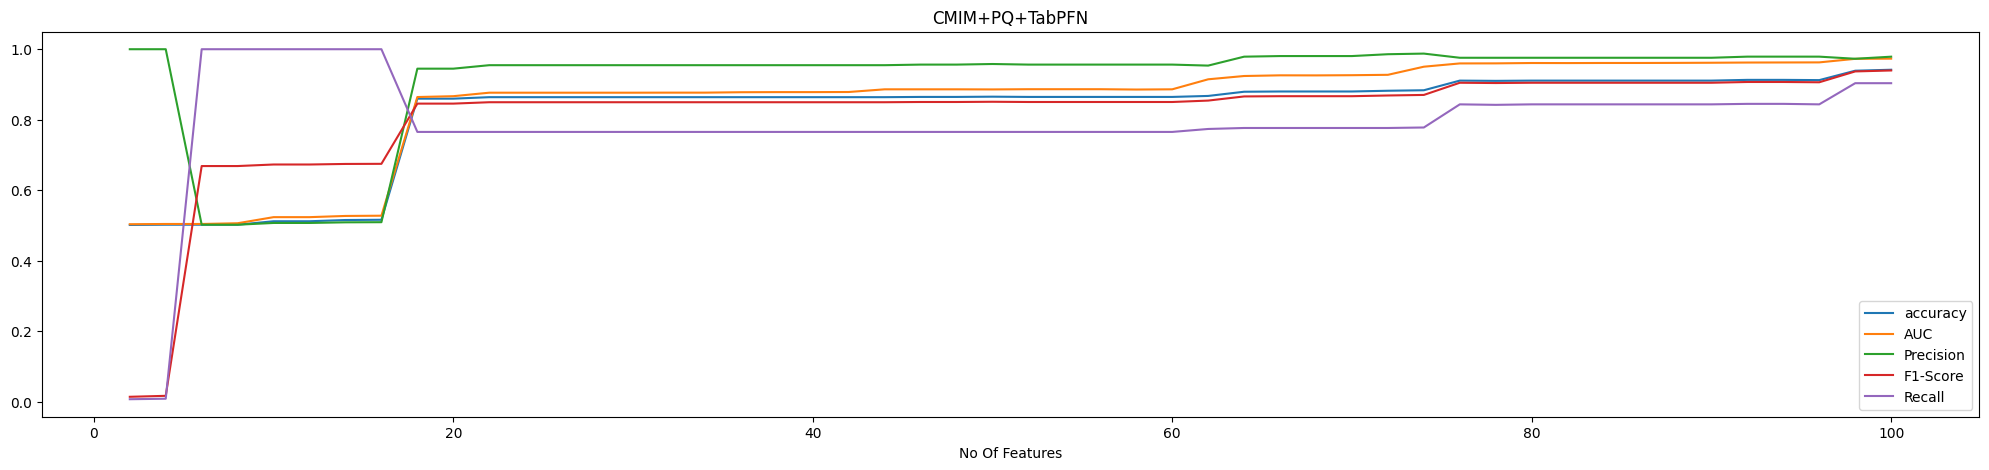

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")
plt.plot(auc_tabPFN, label="AUC")
plt.plot(Precision_tabPFN, label="Precision")
plt.plot(f1Score_tabPFN, label="F1-Score")
plt.plot(Recall_tabPFN , label="Recall")

plt.title("CMIM+PQ+TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("")
plt.legend()
plt.show()

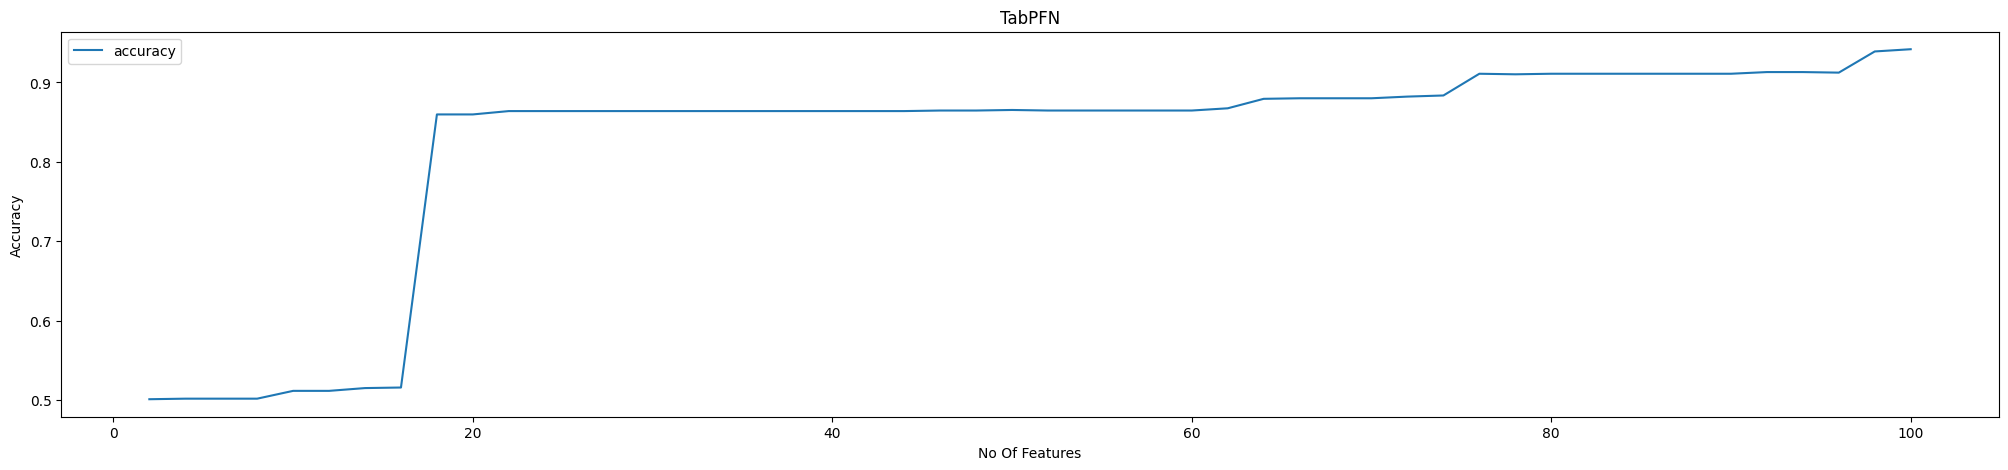

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

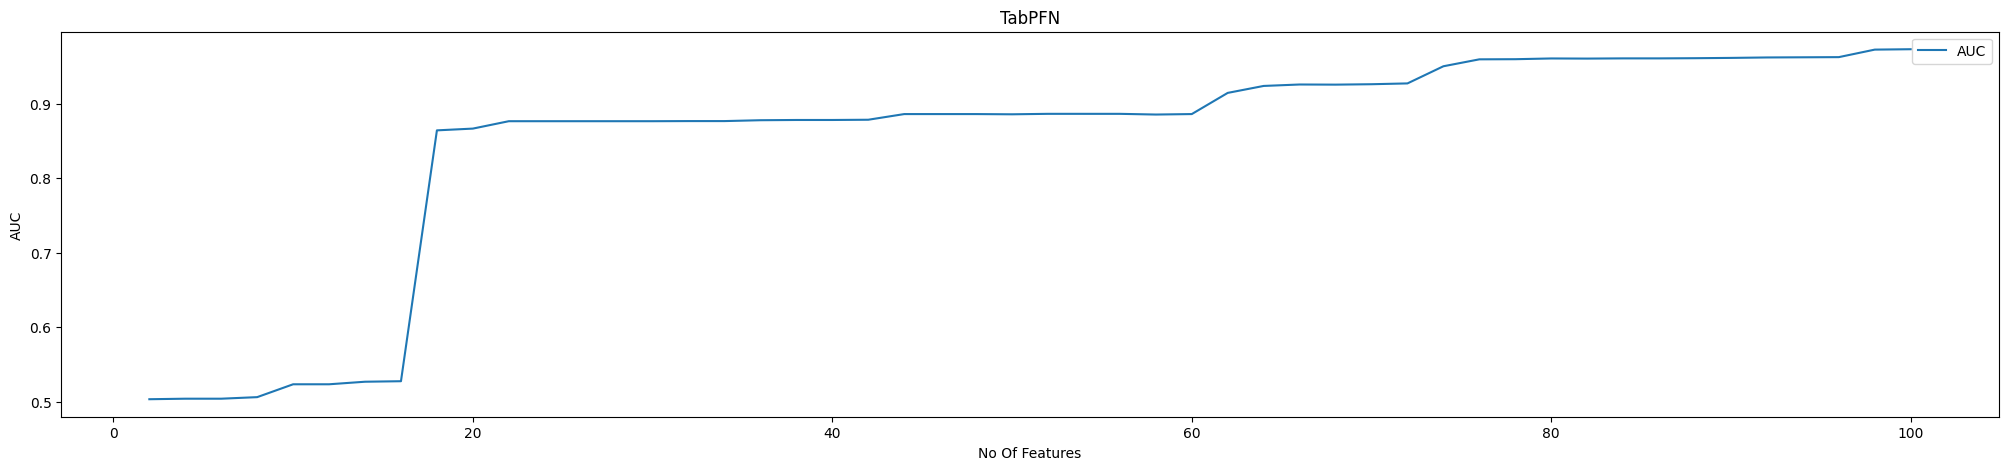

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(auc_tabPFN, label="AUC")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("AUC")
plt.legend()
plt.show()

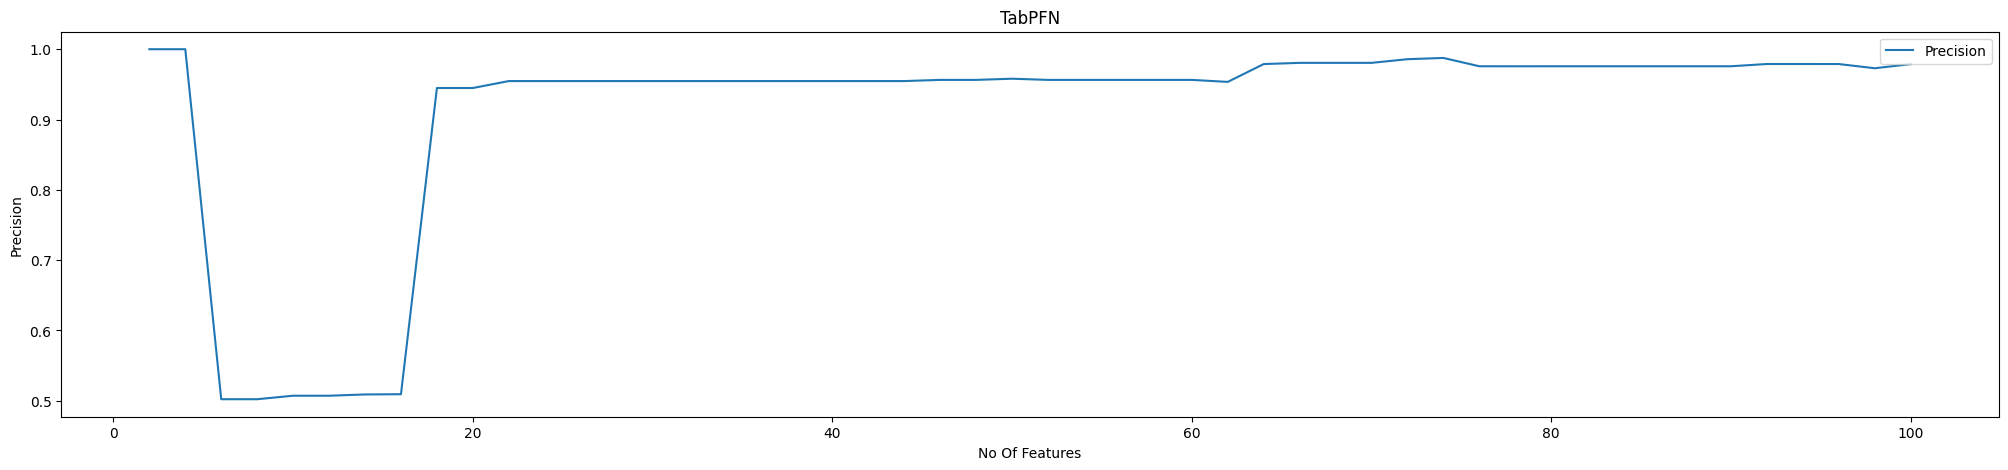

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Precision_tabPFN, label="Precision")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Precision")
plt.legend()
plt.show()

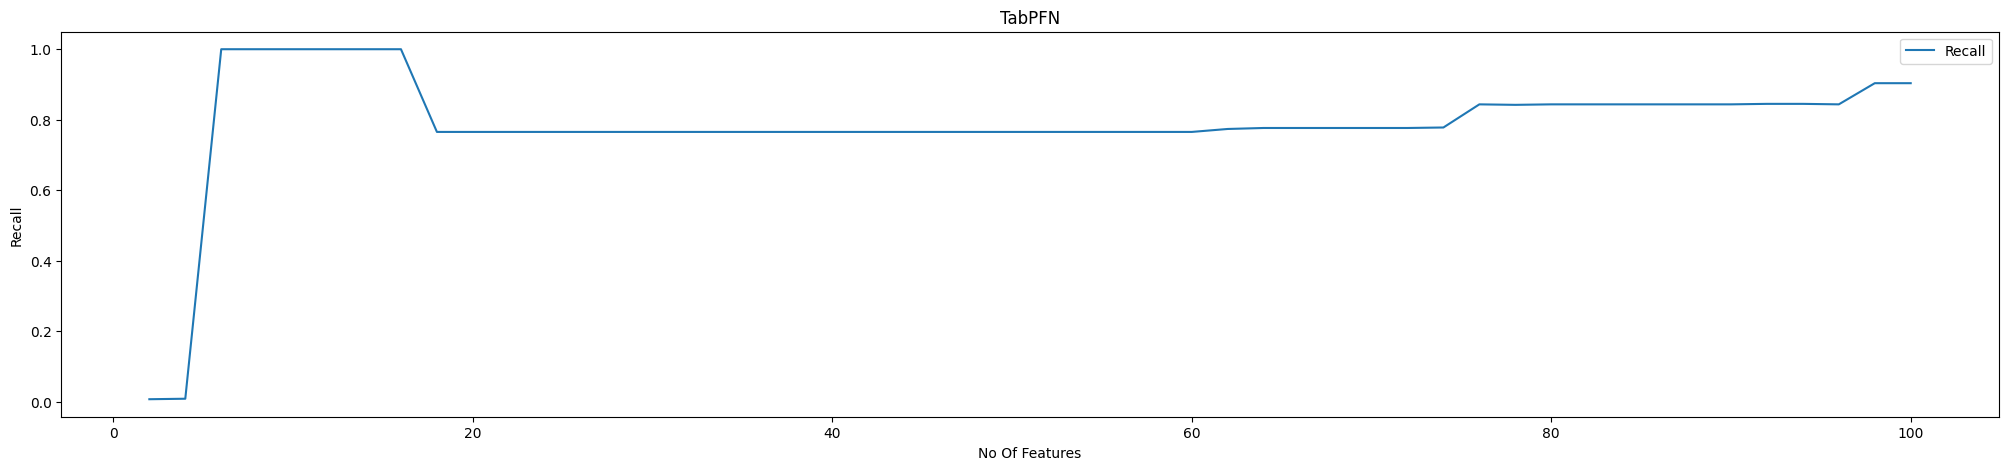

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Recall_tabPFN , label="Recall")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Recall")
plt.legend()
plt.show()

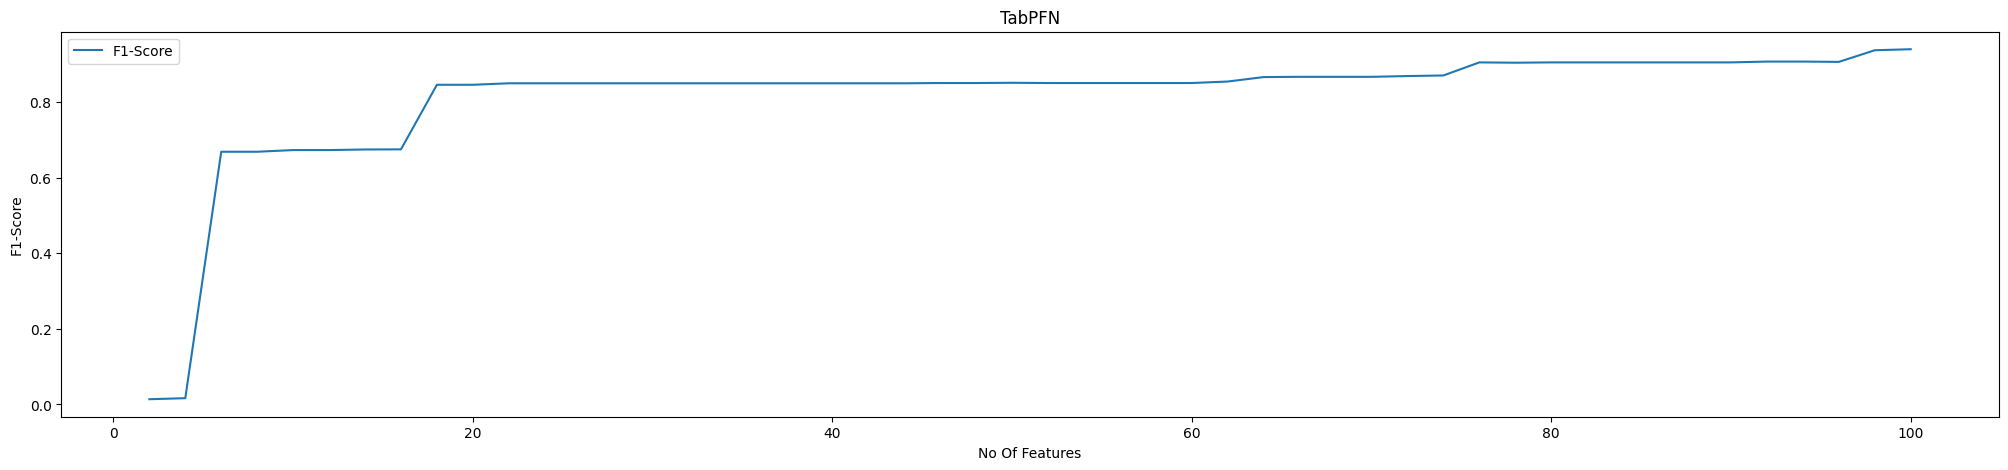

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(f1Score_tabPFN, label="F1-Score")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("F1-Score")
plt.legend()
plt.show()